# IndieGuard: Indie Game Launch Analytics
## Review 1: data, cleaning, EDA, features, models, evaluation and first findings

*Predicting negative-review risk and identifying winning feature combinations on Steam.* Business Analytics capstone, team of five.

This notebook tells the Review 1 story from the data we collected to the first business findings. It **reads the committed data and
results** (it does not retrain the models), so it runs in about a minute. Where a step has its own code and documentation, the
section says where.

| Section | What it shows |
| --- | --- |
| 1 | Problem and business objective |
| 2 | The data we collected |
| 3 | Cleaning and preprocessing |
| 4 | Exploratory analysis |
| 5 | Feature engineering and dimensionality reduction |
| 6 | Targets and the train/test split |
| 7 | Models and comparison |
| 8 | Evaluation and interpretation |
| 9 | Initial business findings and recommendations |
| 10 | Limitations and what Review 2 adds |
| 11 | Reproducibility |

## 1. Problem and business objective

Reviews decide a game's visibility and reputation, and Steam lets a player **refund a game within 14 days if they have played
under 2 hours**. A negative review written in those first two hours costs a small studio twice: a worse rating and often the sale.
Studios decide what to build, what to fix before launch and when to patch mostly by instinct.

**Business objective:** give a small studio or publisher evidence to decide **which feature combinations to back, what to fix before the
refund window closes, and when to patch**, using only public Steam data that we collected ourselves.

Two prediction tasks: **(a) review level**, will a review be negative; **(b) game level**, which success tier will a game land in
(Struggling, Solid, Strong). Review 2 adds association rules, text mining and a dashboard. Full statement: `docs/problem_statement.md`.

In [1]:
import json, subprocess, sys, warnings
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90, "display.width", 200, "display.float_format", "{:,.3f}".format)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "requirements.txt").exists())
PROC, FEAT, RES, FIG, DOCS = ROOT / "data/processed", ROOT / "data/processed/features", ROOT / "reports/results", ROOT / "figures", ROOT / "docs"
show = lambda path, width=950: display(Image(filename=str(path), width=width))
print("Repository root:", ROOT)

Repository root: C:\Users\Shantharam P\Documents\GitHub\IndieGuard


## 2. The data we collected

No pre-built dataset was used. Everything comes from four public Steam sources, collected by our own throttled, resumable scrapers
(`src/collect/`) on 1 and 2 October 2026, and frozen with row counts and SHA256 hashes (`docs/data_manifest.md`).

| Source | Gives |
| --- | --- |
| Steam store search | The game list: indie games with a roguelike-family tag, released 2022 to 2025, at least 10 reviews |
| Steam reviews (`appreviews`) | Every review: text, recommend flag, playtime at review, timestamps, flags |
| Steam appdetails and store page | Price, genres, categories, release date, developer, DLC, platforms, top 20 user tags |
| SteamSpy and Steam news | Owner estimates; developer announcements used for patch and sale dates |

In [2]:
games = pd.read_parquet(PROC / "games_clean.parquet")
reviews = pd.concat([pd.read_parquet(p, columns=["appid", "voted_up", "language", "created", "text_mining_ok"])
                     for p in sorted((PROC / "reviews_clean").glob("*.parquet"))])
events = pd.read_parquet(PROC / "events.parquet")
summary = pd.DataFrame({
    "Games": [f"{len(games):,}", f"released {games.release_date.dt.year.min()} to {games.release_date.dt.year.max()}"],
    "Reviews (cleaned)": [f"{len(reviews):,}", f"{reviews.language.nunique()} languages; {reviews.language.eq('english').mean():.1%} English"],
    "Negative reviews": [f"{(~reviews.voted_up).mean():.1%}", "the minority class"],
    "Patch / sale announcements": [f"{len(events):,}", f"{events.event_type.eq('patch').sum():,} patches, {events.event_type.eq('sale').sum():,} sales"],
    "Review coverage": ["99.95%", "of Steam's own total, for 1,856 fully scraped games (5 very large games capped at their newest ~15,000)"],
}, index=["count", "detail"]).T
display(summary)
print("Games per release year:", games.release_date.dt.year.value_counts().sort_index().to_dict())

,count,detail
Games,"1,861",released 2022 to 2025
Reviews (cleaned),"1,648,387",31 languages; 39.5% English
Negative reviews,10.4%,the minority class
Patch / sale announcements,"29,918","28,875 patches, 1,043 sales"
Review coverage,99.95%,"of Steam's own total, for 1,856 fully scraped games (5 very large games capped at thei..."


Games per release year: {2022: 286, 2023: 372, 2024: 557, 2025: 646}


## 3. Cleaning and preprocessing

The pipeline (`python -m src.clean`) turns the raw JSON into typed tables and then cleans them. **Rows are dropped only when
unusable** (duplicates, empty text, impossible values); anything merely suspicious is kept with a flag so each analysis can choose.
Every rule, with before and after counts and its justification, is logged automatically in `docs/cleaning_log.md`.

In [3]:
log = pd.DataFrame(json.load(open(PROC / "cleaning_log.json")))
print("Rules by type:", log.action.value_counts().to_dict())
display(log[log.affected > 0][["table", "action", "rule", "before", "after", "affected"]].sort_values(["table", "action"]).reset_index(drop=True))

Rules by type: {'flag': 18, 'drop': 8, 'fix': 6}


,table,action,rule,before,after,affected
0,games,fix,launch_date = original launch (Early Access start) where earlier than store date,1861,1861,318
1,games,fix,Strip whitespace in tag/genre/developer lists,1861,1861,56
2,games,flag,Early Access launch before 2022 (1.0 inside window),1861,1861,86
3,games,flag,Review scrape < 99% of Steam total,1861,1861,22
4,games,flag,"Reviews capped (newest 15,000 only)",1861,1861,5
5,news,flag,Developer announcement (not press coverage),45183,45183,44232
6,news,flag,Patch event,45183,45183,28875
7,news,flag,Sale/discount event,45183,45183,1043
8,reviews,drop,Empty review text,1652999,1648387,4612
9,reviews,flag,"Playtime at review above 99.5% quantile (363 h), capped copy added",1648387,1648387,8242


Main points: only **4,612 empty reviews were dropped** (of 1,652,999); 318 games got their true launch date (Early Access start) in place of
the 1.0 date; and low-content, copy-pasted, symbol-spam, pre-launch and extreme-playtime reviews are flagged, not removed. The
`text_mining_ok` flag marks English reviews with analysable text.

## 4. Exploratory analysis

The full analysis (29 figures, association tests, tag-combination tests with a false-discovery-rate correction) is in
`notebooks/02_EDA_Visualizations.ipynb`. Four views that matter most:

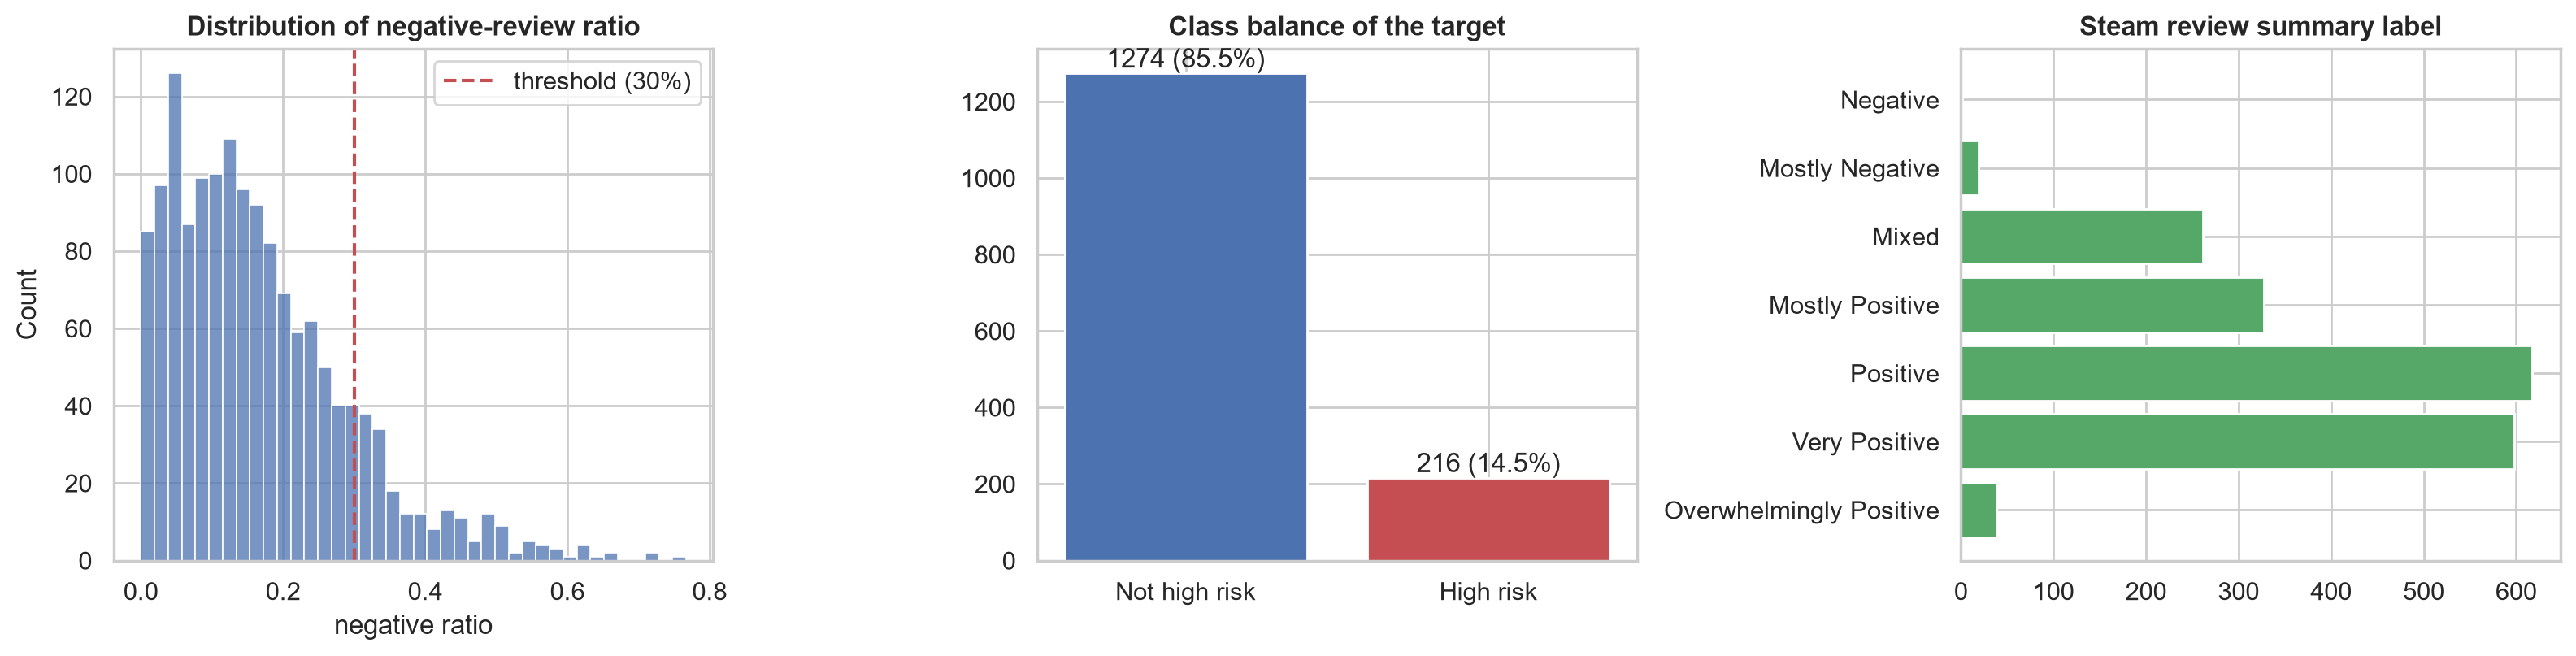

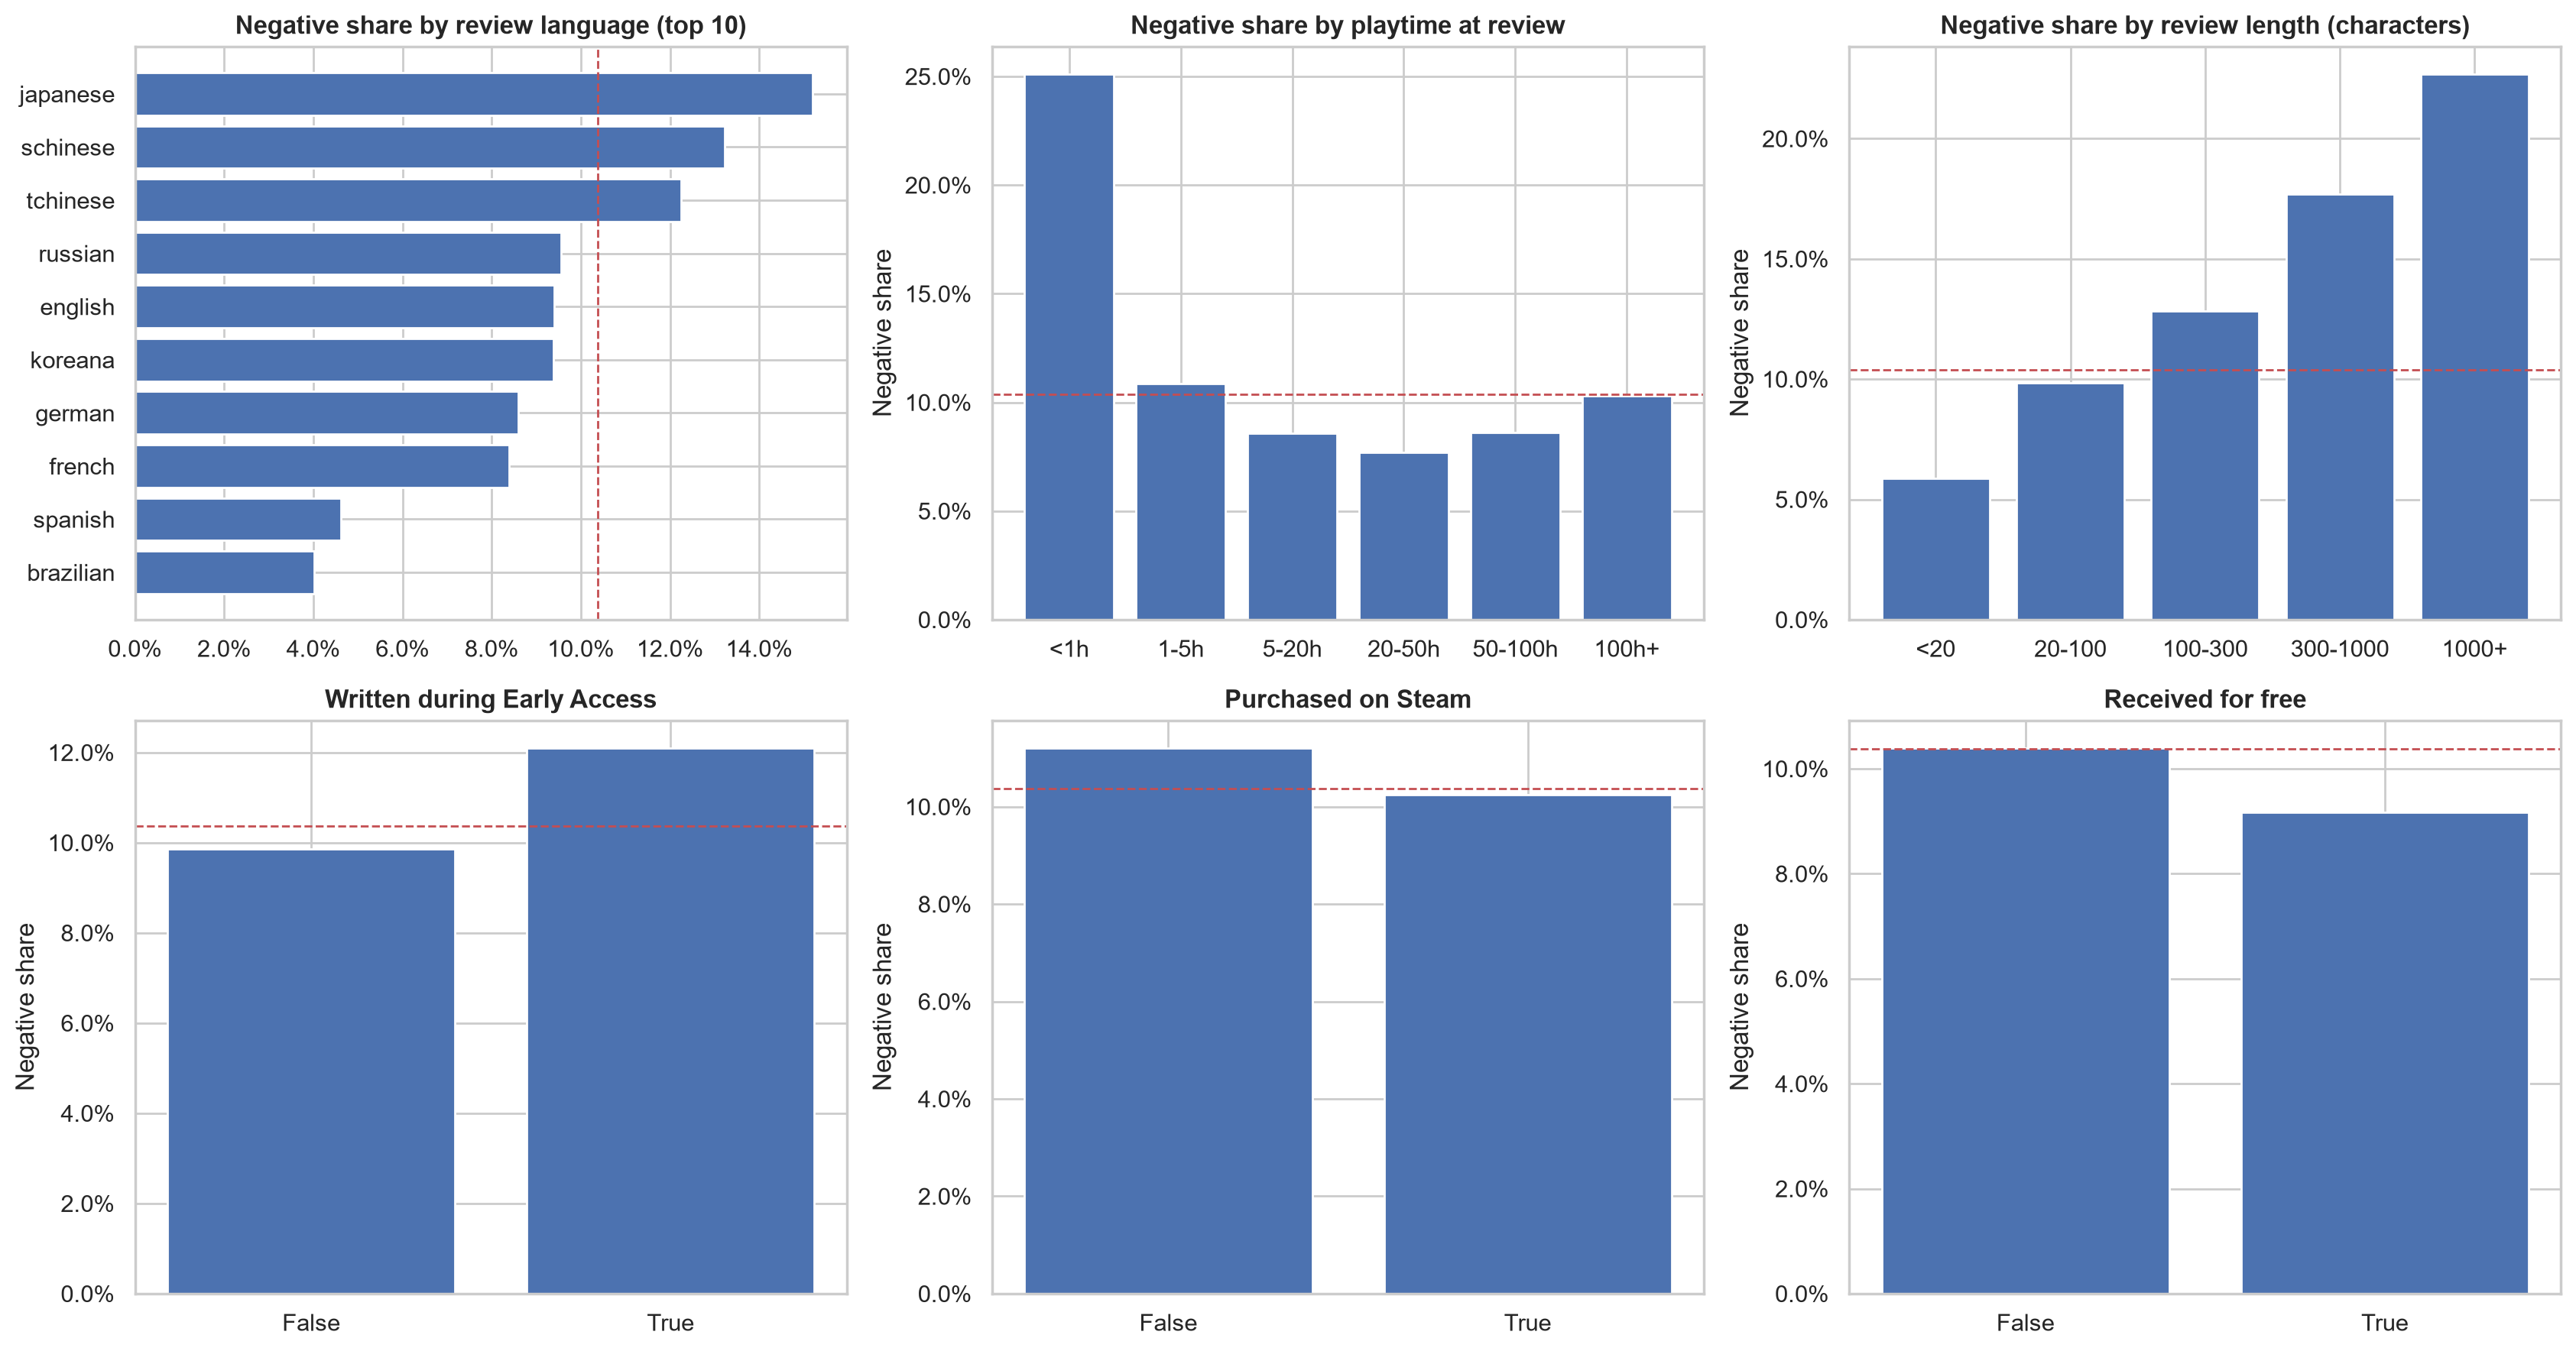

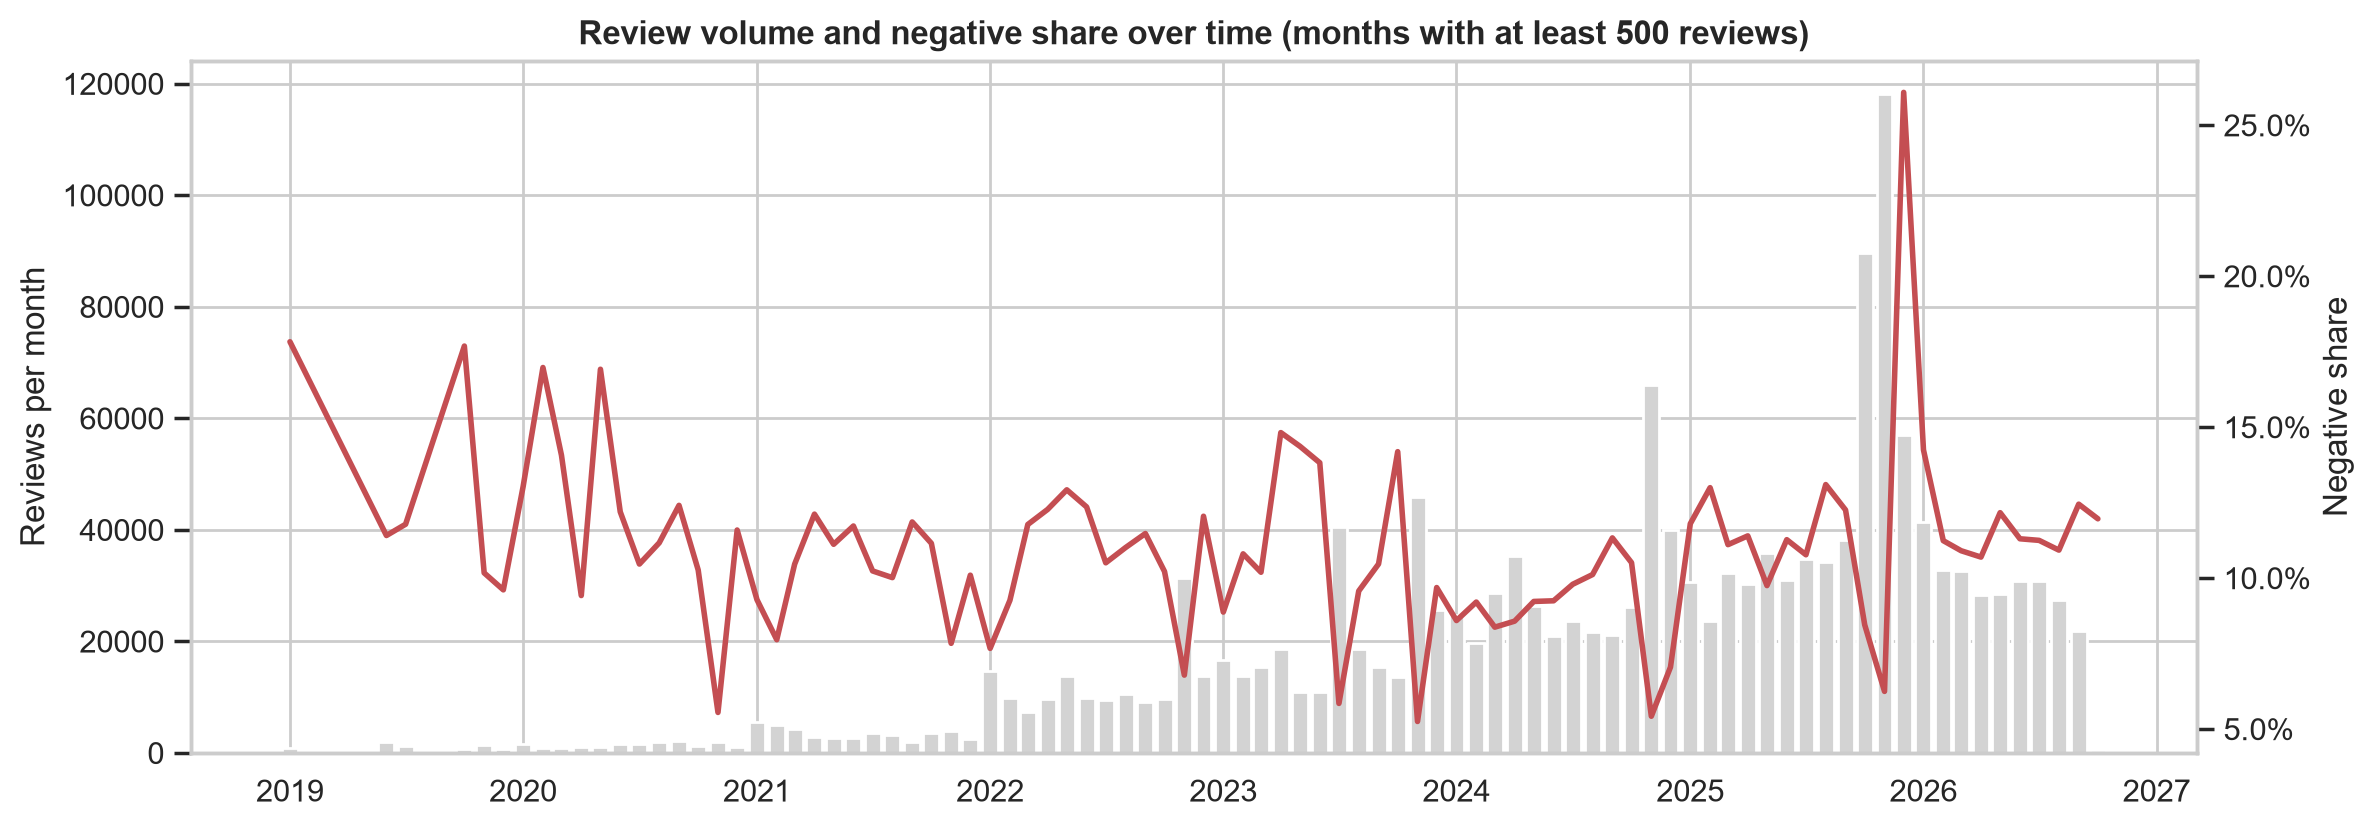

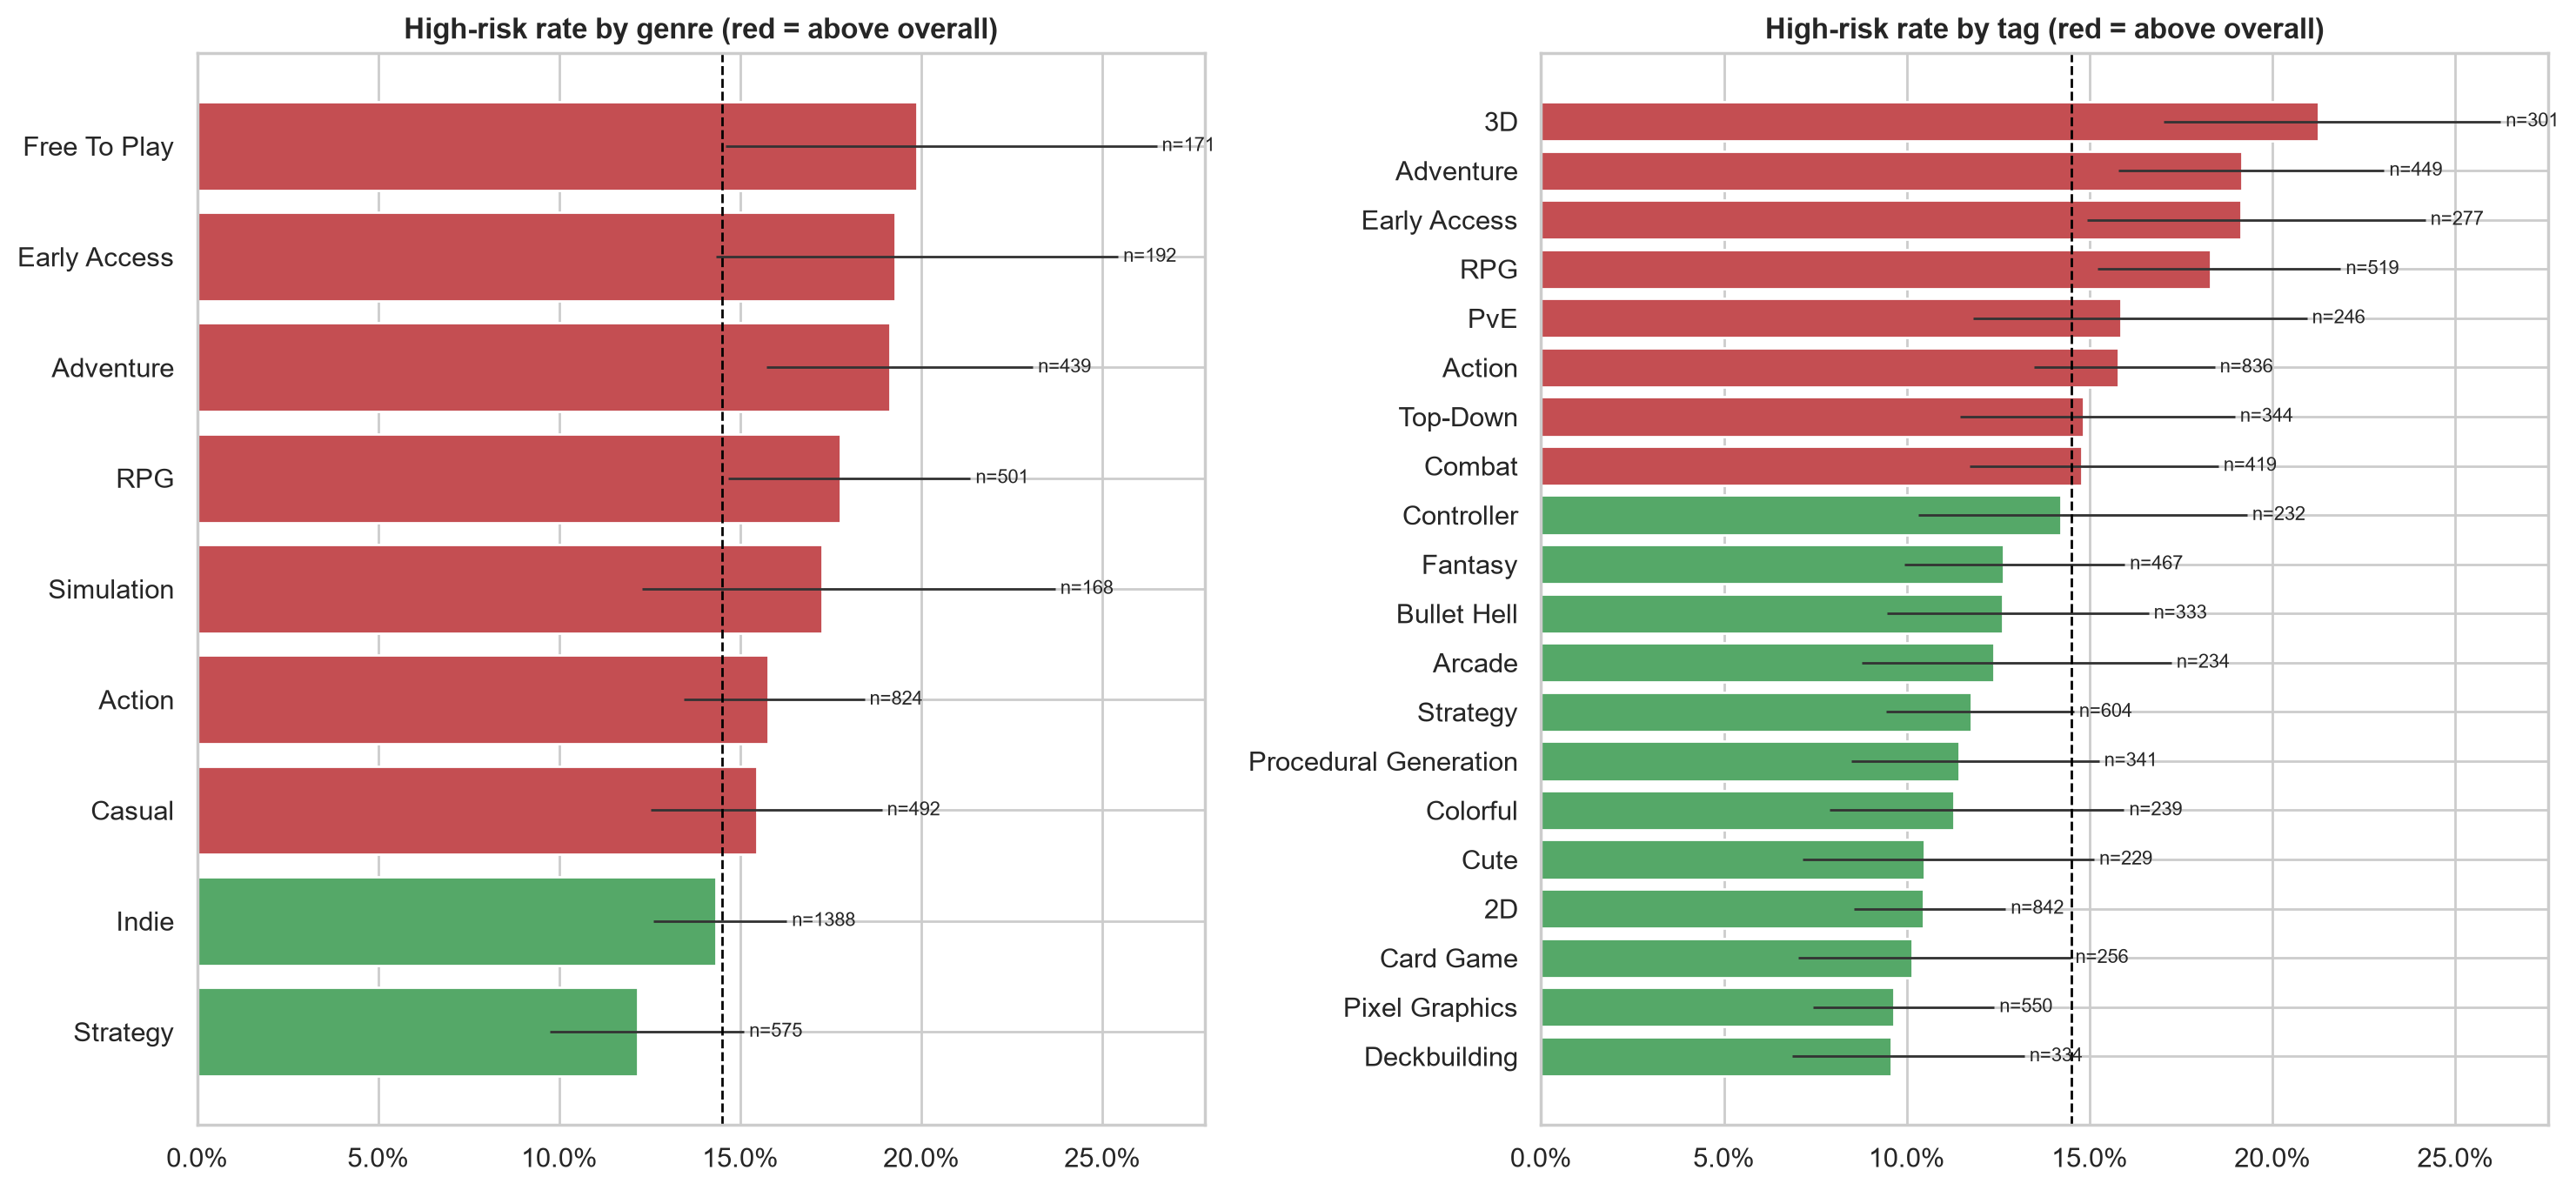

In [4]:
for name in ["03_target_definition.png", "14_review_level_negative_share.png", "17_monthly_review_trend.png", "12_risk_by_genre_and_tag.png"]:
    show(FIG / "eda" / name)

What the EDA established: negative-review share varies strongly with playtime and review length; games with few reviews have noisy
ratios (hence the 20-review minimum for the game-level target); tags and a handful of store attributes go with higher or lower risk,
but the effects are small to moderate; and review volume, owners and similar numbers are consequences of reception, so they cannot be used to predict it.

## 5. Feature engineering and dimensionality reduction

Built by `python -m src.features` (about 3 minutes, 21 automatic checks). Everything learned from data is **fitted on training games
only**. Three kinds of feature:

- **Engineered features** (kept as they are): playtime bucket, refund-window flag, days since launch, launch-week flag, price tier, patch and sale recency, reviewer and text-length features.
- **Tags and categories, reduced with PCA:** 439 candidate columns, 199 rare, 3 near-constant and 3 duplicate columns removed, leaving 234; PCA at the elbow of the variance curve keeps **68 components** (75% of the training variance, 70.5% on held-out games).
- **Review text, reduced with TF-IDF and SVD:** 41,891 terms to 78 components on 557,202 English reviews.

,table,group,entries
0,game_features,key,1
1,game_features,launch_time,17
2,game_features,post_launch,3
3,game_outcomes,outcome,1
4,game_targets,key,1
5,game_targets,target,2
6,review_features,at_review,16
7,review_features,key,1
8,review_features,target,1
9,text_svd,at_review,1


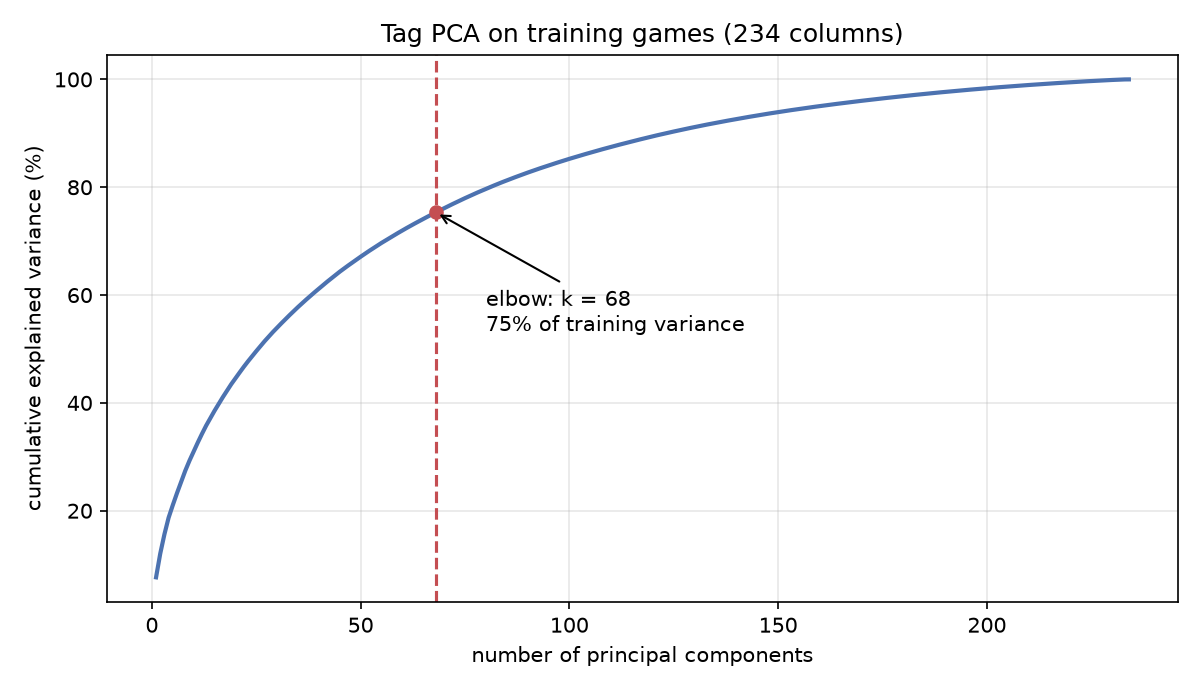

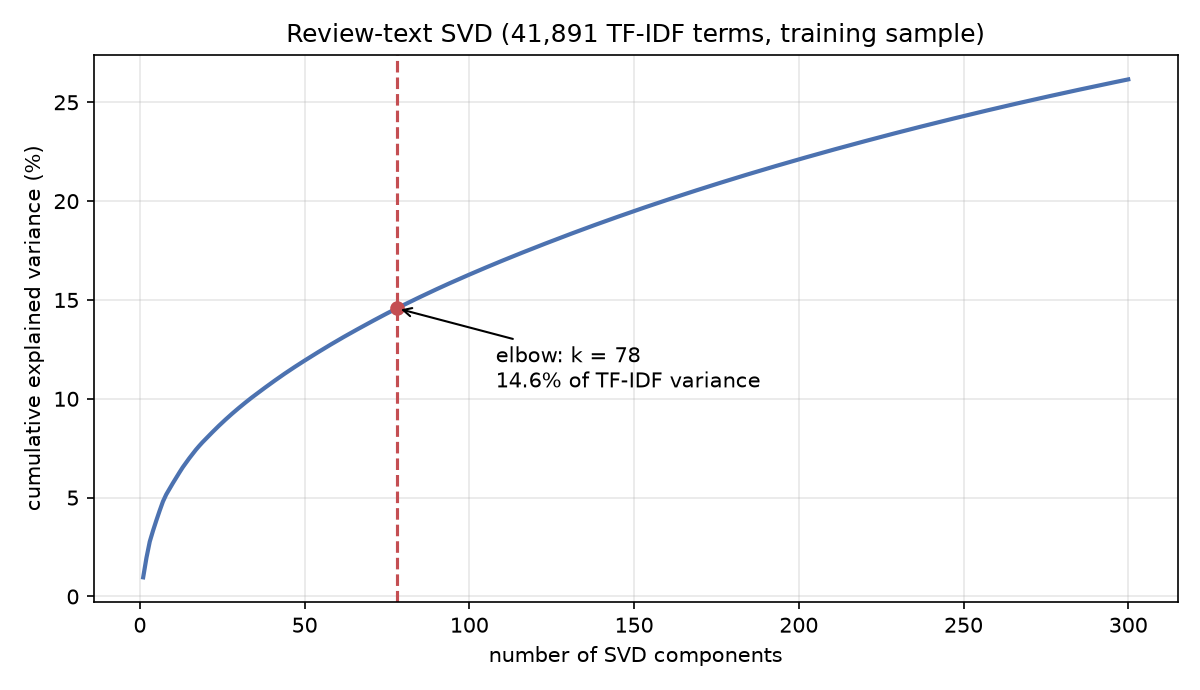

In [5]:
cat = pd.read_csv(DOCS / "feature_engineering/feature_catalog.csv")
display(cat.groupby(["table", "group"]).size().rename("entries").reset_index())
show(DOCS / "figures/tag_pca_variance.png", 640)
show(DOCS / "figures/text_svd_variance.png", 640)

The first four tag components are interpretable: **action roguelike and bullet hell versus card and strategy games**; **a polished store page
(cloud saves, controller support, achievements) versus 3D and free-to-play**; **2D pixel art versus 3D**; **RPG and fantasy versus casual shooters**.
The text curve is shallow, which is normal for short reviews. Details and limitations: `docs/feature_engineering.md`.

## 6. Targets and the train/test split

- **Review level:** the label is `target_is_negative` (10.6% of reviews).
- **Game level:** three ordered success tiers on Steam's positive share, for games with at least 20 reviews: **Struggling** (30% or more negative), **Strong** (10% or less negative), **Solid** (between). Fixed in advance, with whole-number arithmetic at the boundaries (`docs/game_target.md`).
- **Split by game**, 80% train and 20% test, plus 5 cross-validation folds inside train, so no game's reviews appear on both sides. Stratified by year, size and rating; the five capped games are always in train.

In [6]:
split = pd.read_csv(PROC / "splits/game_split.csv")
targets = pd.read_parquet(FEAT / "game_targets.parquet")
bal = pd.read_csv(DOCS / "feature_engineering/game_target_balance.csv").set_index("tier")
display(split.split.value_counts().rename("games").to_frame().T)
display(bal)

split,train,test
games,1489,372


,test,train,total,share
tier,,,,
Struggling,51,165,216,0.145
Solid,147,605,752,0.505
Strong,101,421,522,0.350


## 7. Models and comparison

Every model uses the **same features, the same shared split and folds, and the same rules**: tuned by cross-validation on the training
part only, the test set scored once (`docs/modelling_protocol.md`). The **Dummy** row is the baseline to beat.
Models: Logistic Regression, Random Forest and XGBoost (the brief), plus LightGBM. XGBoost is on default settings and the others were tuned.

Review level, metadata only (PR-AUC; guessing = 0.106)


,Tuned,CV mean,CV sd,Test,Test ROC-AUC,Per-game ROC-AUC
Model,,,,,,
Dummy (prior),default settings,0.107,0.024,0.106,0.500,0.500
Logistic Regression,tuned,0.208,0.024,0.194,0.663,0.684
Random Forest,tuned,0.285,0.040,0.275,0.721,0.745
LightGBM,tuned,0.285,0.034,0.265,0.729,0.744
XGBoost,default settings,0.285,0.031,0.283,0.733,0.743


Game level, three tiers (macro-F1; guessing = 0.22)


,Tuned,CV mean,CV sd,Test,CI low,CI high,Test bal-acc,Recall Struggling,Recall Solid,Recall Strong
Model,,,,,,,,,,
Dummy (prior),default settings,0.225,0.003,0.220,0.201,0.236,0.333,0.000,1.000,0.000
Logistic Regression,tuned,0.422,0.033,0.423,0.365,0.477,0.439,0.390,0.400,0.520
Random Forest,tuned,0.421,0.038,0.404,0.342,0.464,0.405,0.140,0.570,0.500
LightGBM,tuned,0.447,0.019,0.421,0.359,0.478,0.444,0.450,0.370,0.510
XGBoost,default settings,0.418,0.044,0.388,0.326,0.448,0.390,0.140,0.560,0.480


Review level on English reviews, adding the text (PR-AUC; guessing = 0.115)


,CV mean,CV sd,Test,Test ROC-AUC,Per-game ROC-AUC
Model,,,,,
Dummy (prior),0.101,0.018,0.115,0.500,0.500
"LightGBM, metadata only",0.332,0.026,0.360,0.758,0.793
"LightGBM, metadata + text components",0.574,0.026,0.581,0.892,0.898
"Logistic Regression, full text + metadata",0.757,0.025,0.785,0.955,0.958


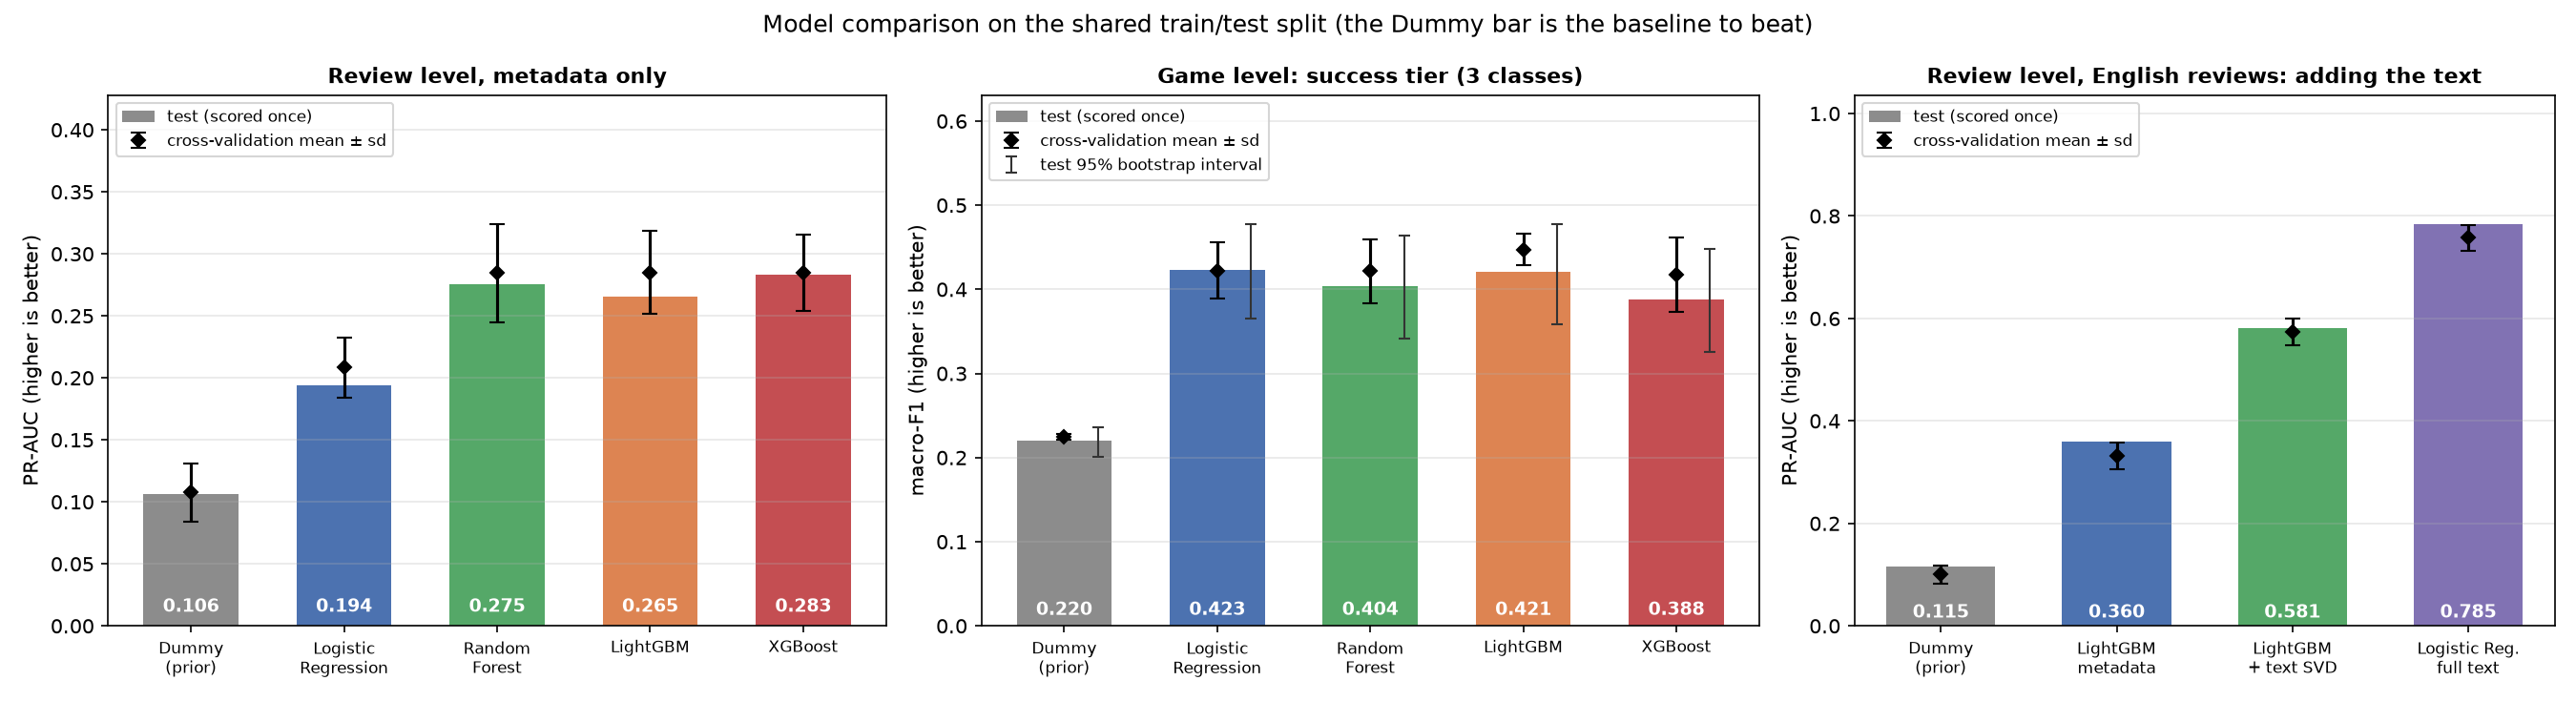

In [7]:
def load(name):
    d = pd.read_csv(RES / name)
    return d.set_index("Model")
rev, gm, txt = load("comparison_review.csv"), load("comparison_game.csv"), load("comparison_review_text.csv")
print("Review level, metadata only (PR-AUC; guessing = 0.106)")
display(rev[["Tuned", "CV mean", "CV sd", "Test", "Test ROC-AUC", "Per-game ROC-AUC"]])
print("Game level, three tiers (macro-F1; guessing = 0.22)")
display(gm[["Tuned", "CV mean", "CV sd", "Test", "CI low", "CI high", "Test bal-acc", "Recall Struggling", "Recall Solid", "Recall Strong"]])
print("Review level on English reviews, adding the text (PR-AUC; guessing = 0.115)")
display(txt[["CV mean", "CV sd", "Test", "Test ROC-AUC", "Per-game ROC-AUC"]])
show(FIG / "models/model_comparison.png", 1100)

How to read it:

- **Review level, metadata only:** the three tree-based models are about equal (test PR-AUC 0.265 to 0.283, against 0.106 for guessing); Logistic Regression is weaker (0.194). The gaps between the tree models are smaller than the fold-to-fold spread.
- **Game level:** every model beats the Dummy baseline (macro-F1 0.22) by 0.17 to 0.20, and the simple models do at least as well as the boosted ones. The test intervals overlap completely (299 test games, 51 Struggling), so **there is no winner**. Struggling games are the hard part: Random Forest and XGBoost find 14% of them, Logistic Regression and LightGBM 39 to 45%, at the cost of Solid recall.
- **Adding the review text is the biggest improvement of all:** on the same English reviews, PR-AUC goes from **0.360** (metadata only) to **0.581** (78 compressed text components) to **0.785** (full text, ROC-AUC 0.955). Note this detects negative reviews from their own text; it does not forecast them.

## 8. Evaluation and interpretation

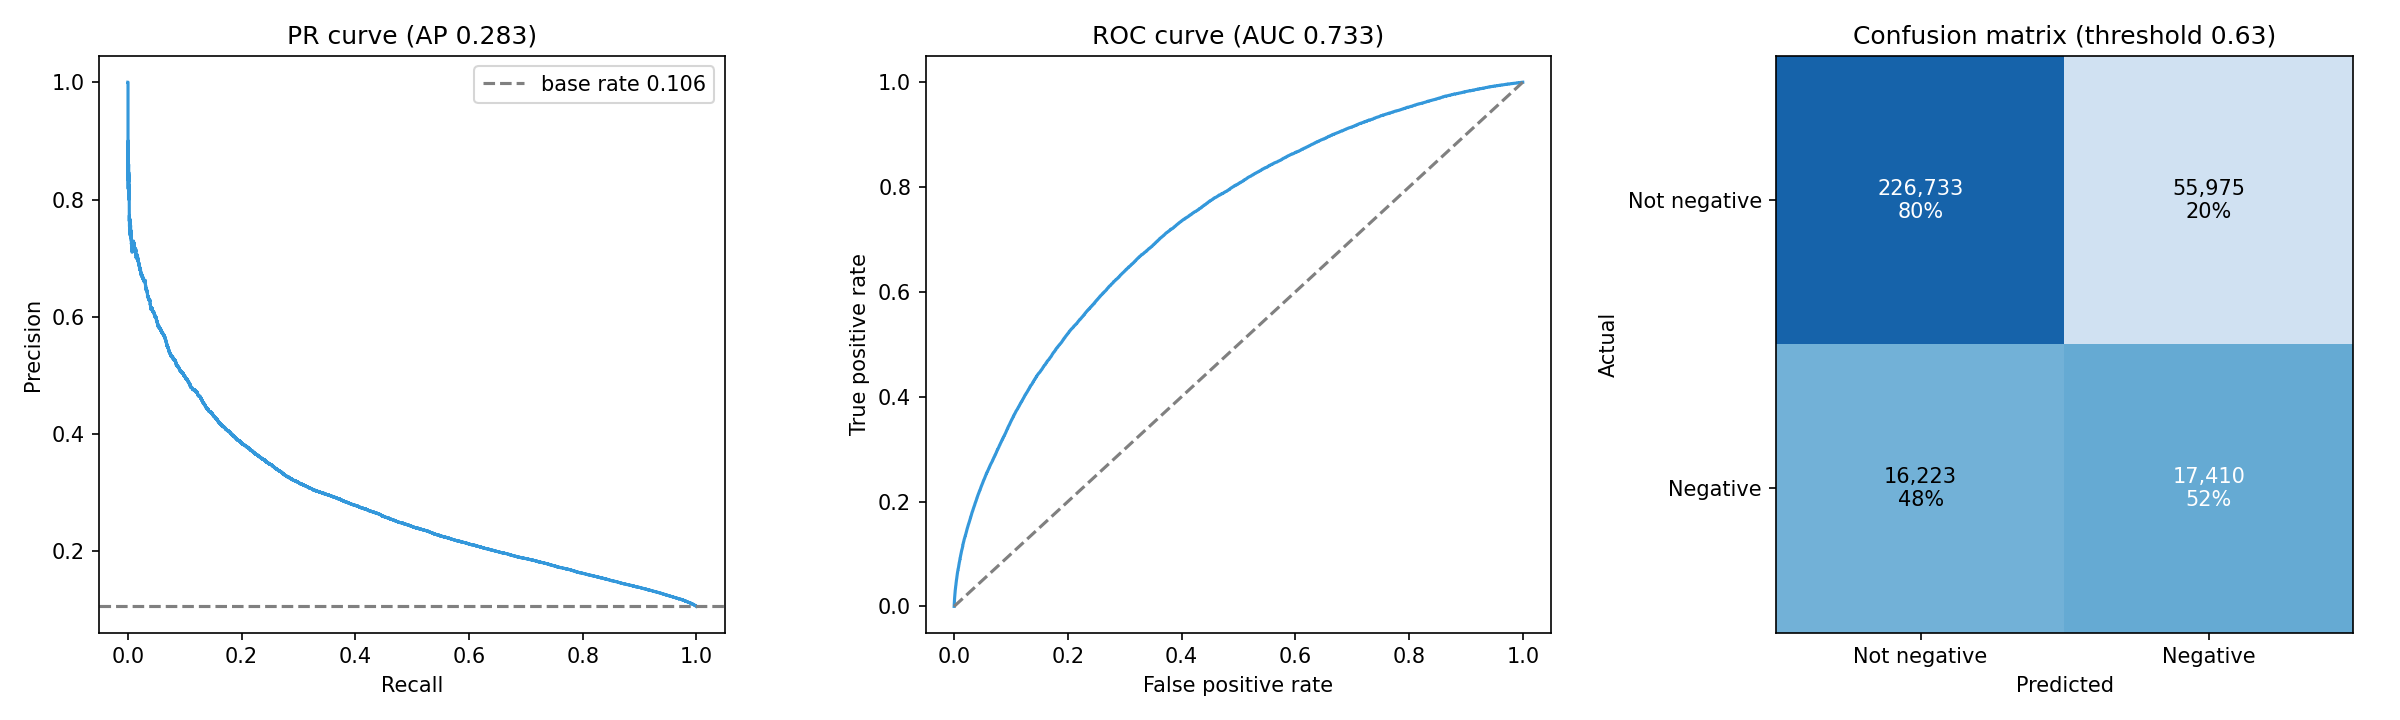

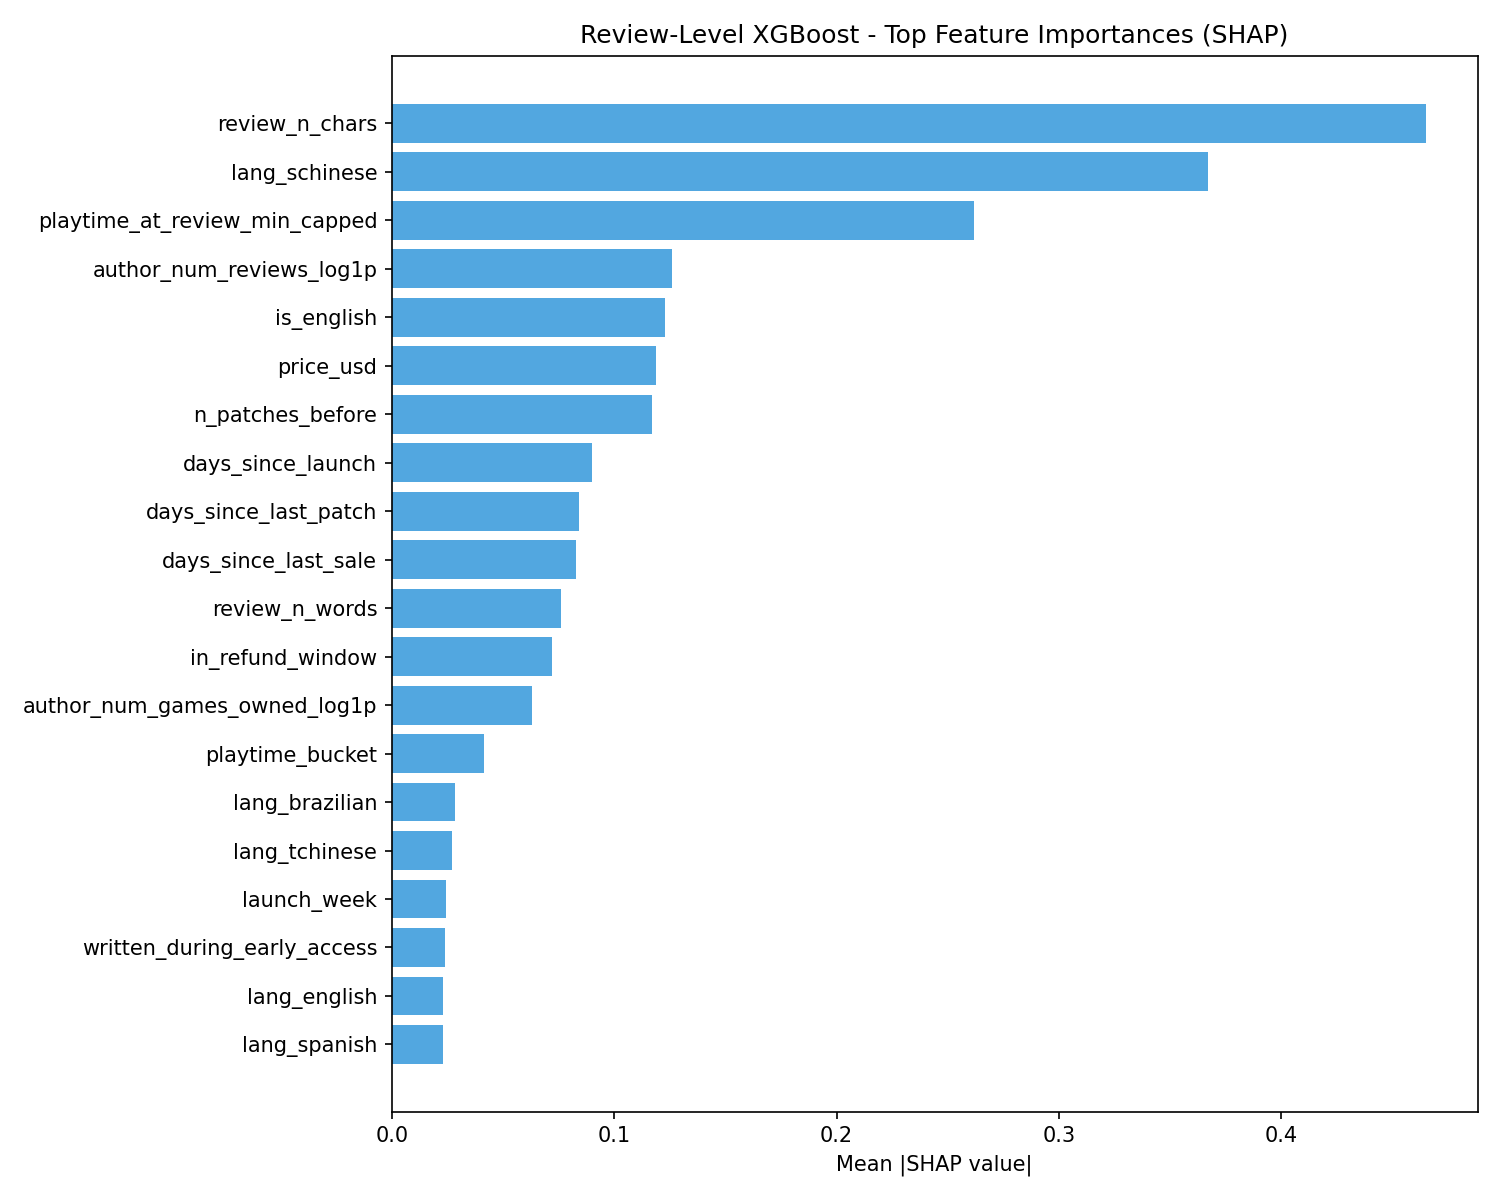

In [8]:
show(FIG / "models/review_xgb_curves.png", 1100)
show(FIG / "models/review_xgb_shap_bar.png", 700)

**Review level (XGBoost, metadata only).** PR-AUC 0.283 and ROC-AUC 0.733 against a 0.106 base rate. At the threshold chosen on training
data it catches 52% of negative reviews with 24% precision (about one flagged review in four really is negative), which is useful for
triage, not for deciding anything alone. The strongest signals are **review length** (negativity rises from 6.0% for very short reviews to
22.8% above 1,000 characters), **language** (Chinese reviews are more often negative), **playtime at review** and the reviewer's number of reviews.

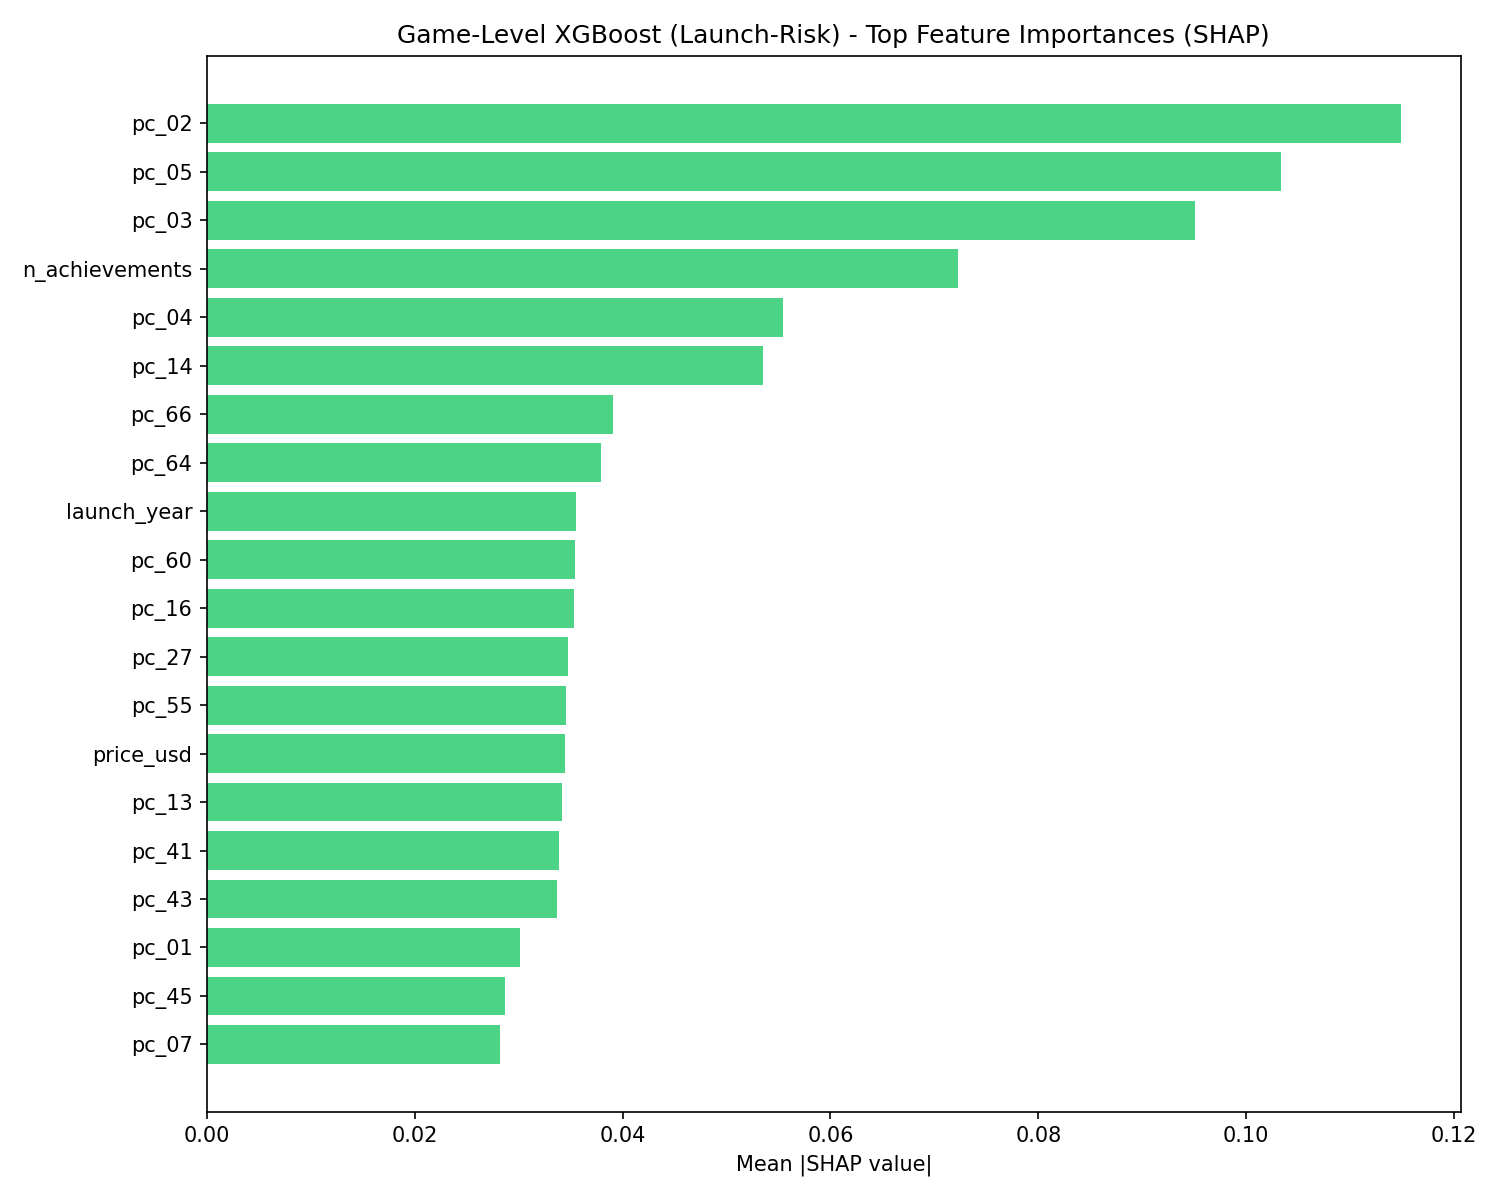

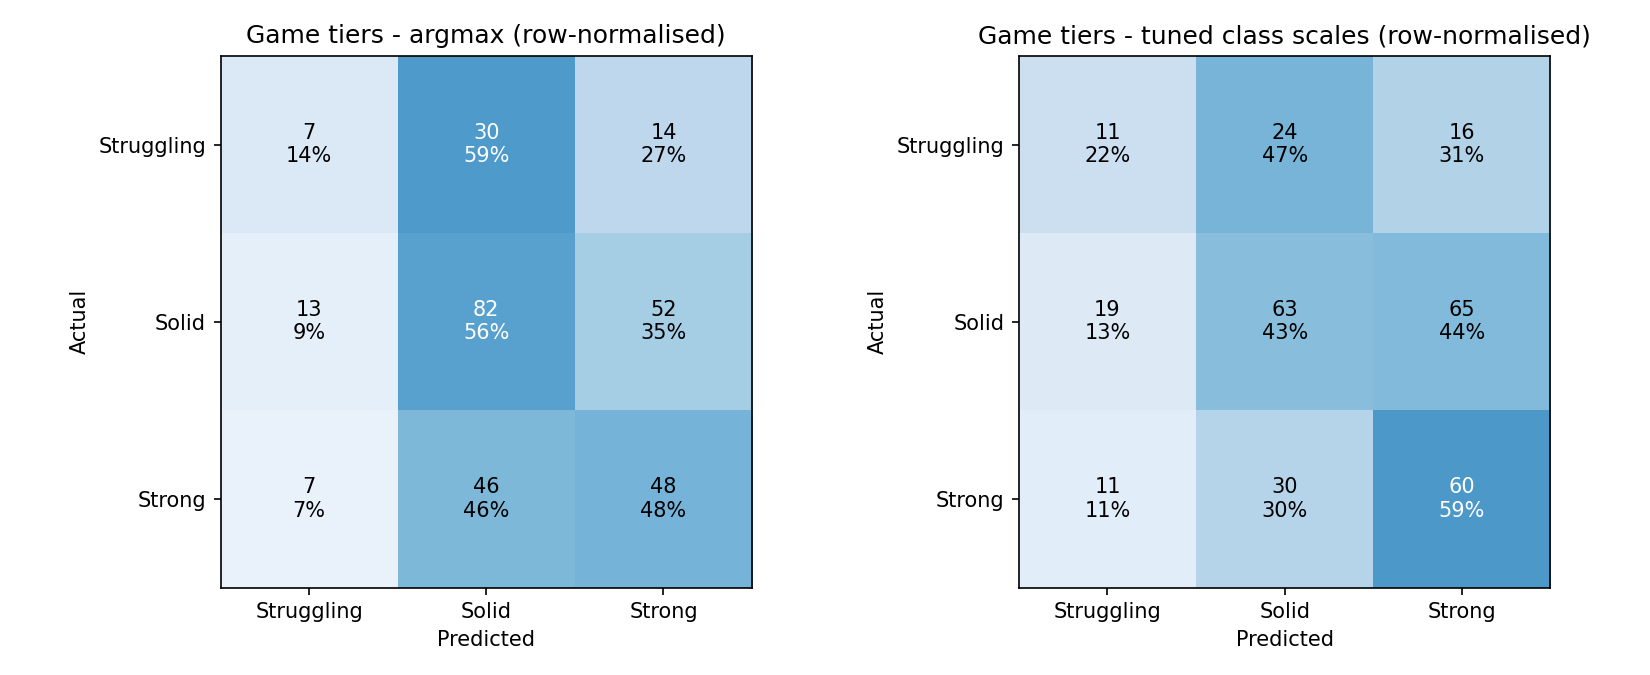

In [9]:
show(FIG / "models/game_xgb_shap_bar.png", 700)
show(FIG / "models/game_xgb_confusion.png", 900)

**Game level.** A store page shows little of how good a game is, and the data confirm it: tag components alone give nearly all the signal
(macro-F1 0.412 against 0.418 for everything), the learning curve is flat (238 to 952 training games: 0.409 to 0.418), so **more games would not
help**. The leading features are the tag components for a polished store page, roguelite and bullet-hell games, and 2D pixel games against 3D,
plus the number of achievements. A weak, honest signal is itself a finding: launch metadata does not decide a game's fate.

**Why the review-level scores are low without the text.** The metadata models cannot see what the reviewer wrote. When the text is included
the same task reaches PR-AUC 0.785, so the low metadata scores are a feature gap that we measured, not a data problem.

## 9. Initial business findings and recommendations

Descriptive, not causal; every number is in `reports/results/findings_*.csv` and explained in `docs/business_findings.md`.

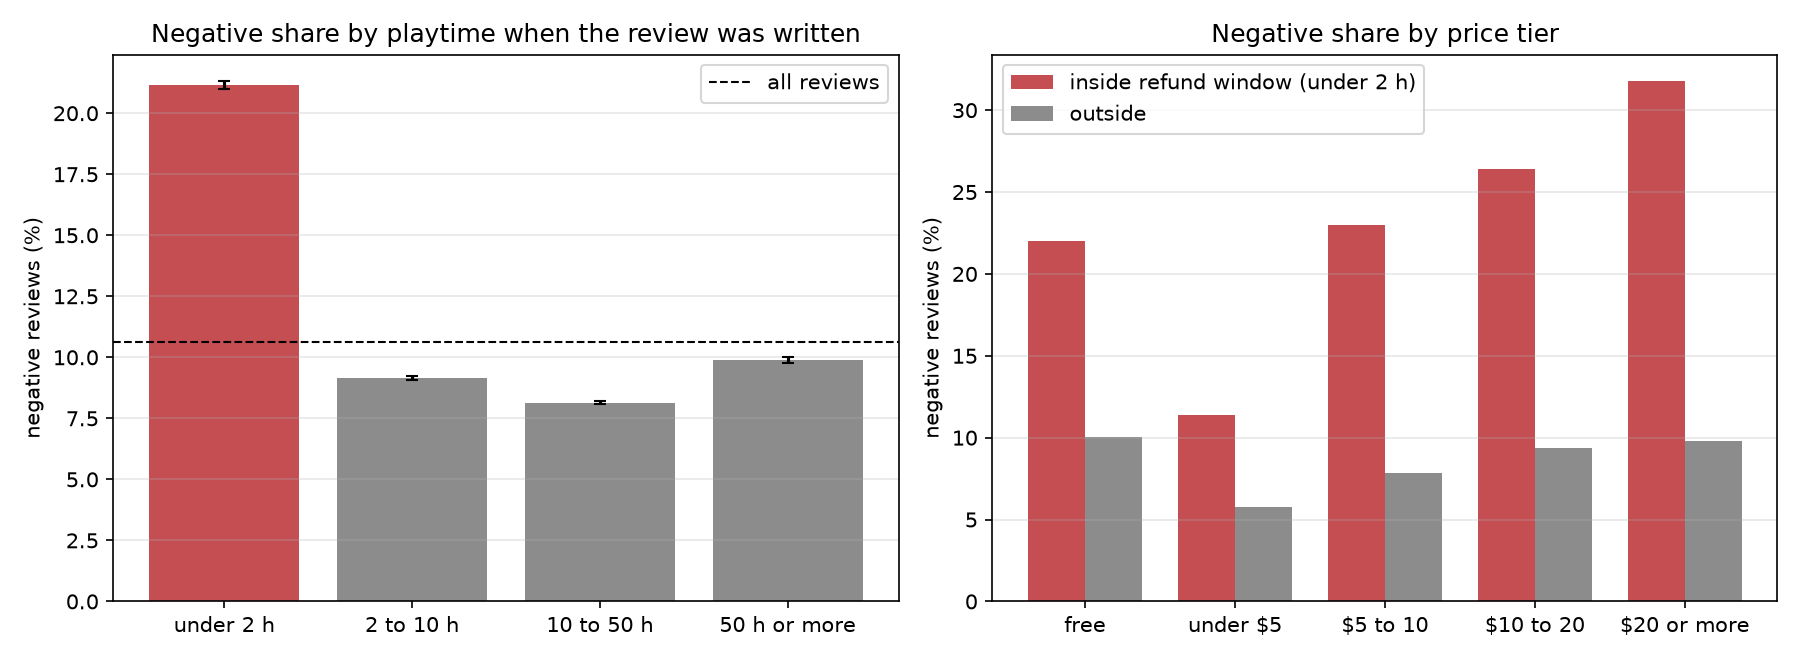

,level,reviews,negative_rate
0,share of all negative reviews written inside the refund window,167114,0.290
1,"share of games (n=493, 50+ reviews each side) where the window is more negative",493,0.943
2,median per-game gap: negative rate inside minus outside the window,493,0.131


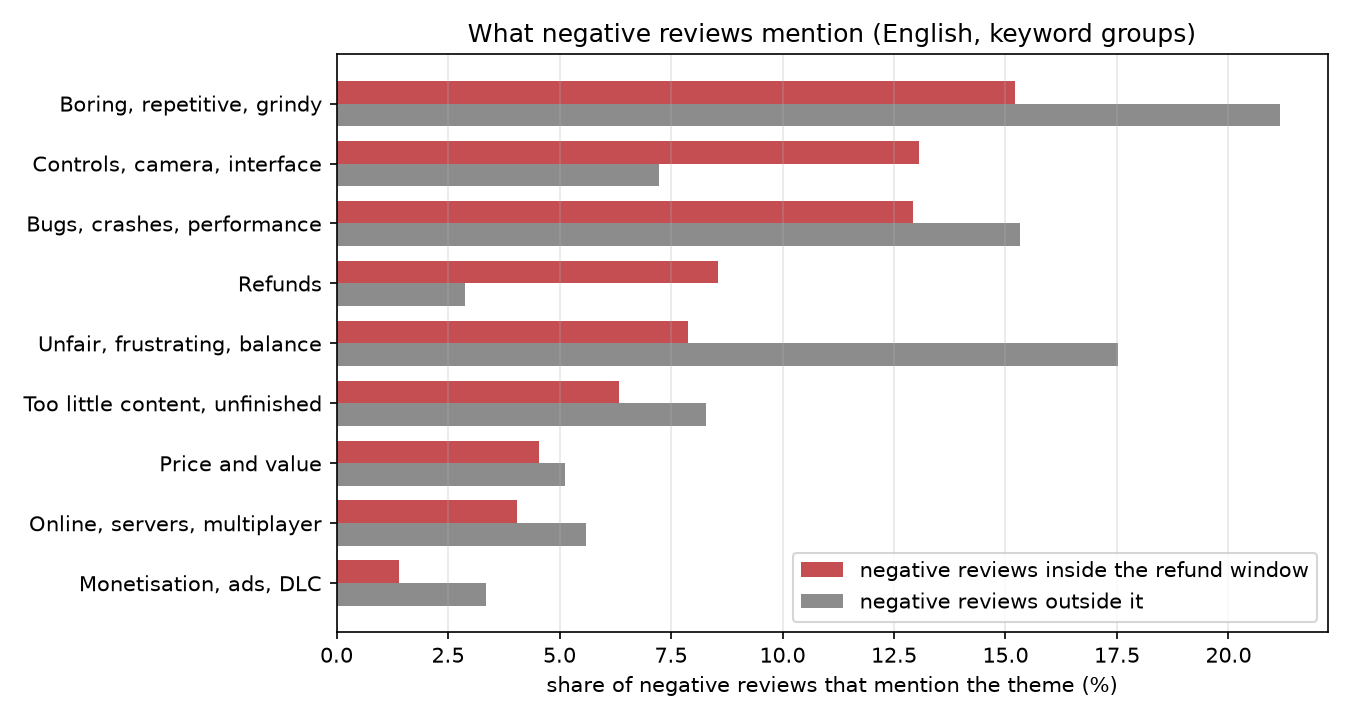

,theme,share_of_reviews,negative_rate_when_mentioned,share_of_negative_inside_window,share_of_negative_outside_window
0,"Bugs, crashes, performance",0.055,0.269,0.129,0.153
1,"Boring, repetitive, grindy",0.051,0.378,0.152,0.212
2,Price and value,0.008,0.662,0.045,0.051
3,"Unfair, frustrating, balance",0.046,0.310,0.079,0.175
4,"Controls, camera, interface",0.034,0.281,0.131,0.072
5,"Too little content, unfinished",0.037,0.211,0.063,0.083
6,"Online, servers, multiplayer",0.038,0.134,0.041,0.056
7,"Monetisation, ads, DLC",0.012,0.216,0.014,0.033
8,Refunds,0.007,0.695,0.086,0.029
9,Praise (control group),0.452,0.077,0.252,0.393


In [10]:
show(FIG / "findings/refund_window.png", 1000)
rw = pd.read_csv(RES / "findings_refund_window.csv")
display(rw[rw.group == "summary"][["level", "reviews", "negative_rate"]].reset_index(drop=True))
show(FIG / "findings/complaint_themes.png", 760)
th = pd.read_csv(RES / "findings_themes.csv").iloc[1:]
display(th[["theme", "share_of_reviews", "negative_rate_when_mentioned", "share_of_negative_inside_window", "share_of_negative_outside_window"]].reset_index(drop=True))

1. **The first two hours decide a lot.** Reviews written within 2 hours of play are negative 21.2% of the time against 8.8% later, and make up 29.0% of all negative reviews: the studio loses the review and often the sale. The pattern holds in 94% of games.
2. **The pricier the game, the harsher the early verdict:** inside the window, 11.4% negative for games under $5, 31.8% for $20 or more.
3. **Fix the opening first.** Early negative reviews mention controls, camera and interface almost twice as often (13.1% against 7.2%).
4. **Patch for depth afterwards.** Later negative reviews mention repetition (21.2% against 15.2%) and unfair difficulty (17.5% against 7.9%).
5. **Test for stability before launch.** Bugs, crashes and performance appear in 13% to 15% of negative reviews in both phases.
6. **Be wary of scope.** Online co-op, open-world and action-RPG games struggle more often in our sample than small focused ones; listing achievements and controller support goes with fewer struggling games (hypotheses, with wide intervals).
7. **Use the text.** Negative reviews can be detected from their text well (PR-AUC 0.79), so a studio can flag and group complaints automatically.

## 10. Limitations and what Review 2 adds

- Relationships are **associations**; tags, prices and DLC are snapshots from 1 October 2026; older games had longer to collect negative reviews.
- Five very large games have only their newest ~15,000 reviews: they are left out of the review-level tables and kept at game level. The game-level test set has only 51 Struggling games, so test results are noisy; cross-validation is reported next to them.
- Text results cover English reviews (about 40% of the data); about 1% of "English" reviews are in another language, and a little remains in the text features.
- Cross-validation is slightly optimistic (early stopping and tuning choose settings on the validation folds); the test scores are the honest figures.
- **Review 2:** association rules on tag, price and Early Access combinations; topic modelling of complaints with a manual check; patch-impact and discount analysis (which will answer "when to patch" properly); and the Streamlit dashboard.

## 11. Reproducibility

```bash
pip install -r requirements.txt
python -m src.features.text          # text features (not committed, about a minute)
python -m src.features               # all feature tables and 21 checks
python -m src.models.review_models   # review-level models;  also game_models, review_text_models, compare
python -m src.analysis.business_findings
```

In [11]:
import platform, sklearn, lightgbm, xgboost
print("Python", platform.python_version(), "| pandas", pd.__version__, "| scikit-learn", sklearn.__version__,
      "| lightgbm", lightgbm.__version__, "| xgboost", xgboost.__version__)
out = subprocess.run([sys.executable, "-m", "src.features.validate"], cwd=ROOT, capture_output=True, text=True)
print("\n".join(l for l in (out.stdout + out.stderr).splitlines() if l.startswith(("PASS", "FAIL", "SKIP"))) or out.stderr[-400:])
print([l for l in out.stderr.splitlines() if "validate:" in l][-1:] or "")

Python 3.12.10 | pandas 3.0.6 | scikit-learn 1.9.1 | lightgbm 4.7.0 | xgboost 3.4.1


PASS  game_features: one row per game, same games as game_split.csv  (1861 games)
PASS  game_features: split and cv_fold copied from game_split.csv
PASS  game_features: no missing values
PASS  game_features: no outcome columns among the features
PASS  game_outcomes: same games, outcome_ columns only
PASS  game_targets: one row per game, split copied from game_split.csv
PASS  game_targets: a tier exactly for games with 20+ reviews  (1490 eligible games)
PASS  game_targets: tiers match an exact-fraction recomputation
PASS  game_targets: high_risk is Struggling and nothing else
PASS  game_targets: every tier present in train and test
PASS  tag PCA mean equals the TRAINING-game mean
PASS  tag PCA mean differs from the all-games mean (test games were not used)
PASS  tag components reproduce from the saved model  (68 components)
PASS  review_features: exactly the clean reviews of the 1,856 fully scraped games  (1,573,436 reviews)
PASS  review_features: no capped game
PASS  review_features: s